# 2. The forward model: astrometric jitter and photometry

As a spotted star rotates, the photocenter (first moment of the visible
disk) traces a closed curve on the sky, and the disk-integrated flux varies.
The paper (Section 2.1) derives the linear forward model

$$ \boldsymbol{\mu} = A(\beta)\,\mathbf{s}, \qquad
   A(\beta) = \begin{bmatrix} W_\omega & \\ & W_\omega \end{bmatrix}
   \begin{bmatrix} B^x_\beta \\ B^y_\beta \end{bmatrix} $$

separating the time dependence ($W_\omega$, a complex-sinusoid matrix) from
the inclination dependence ($B^h_\beta$). `ForwardModel` assembles all
three channels — photocenter x, y, and photometry `p`.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jittermap as jm


In [2]:
L, N = 15, 200
times = np.linspace(0, 2*np.pi, N, endpoint=False)
s = jm.multispot_surface([(35, 300, 12.0)], L)   # one spot at latitude 35
fm = jm.ForwardModel(times, l_max=L)

## Signals vs. inclination

Reproducing the phenomenology of paper Figure 2: the astrometric signal of
a starspot over a full rotation, for inclinations from equator-on to
pole-on. Note the y-photocenter amplitude grows with inclination while the
photometric modulation shrinks — and vanishes pole-on.

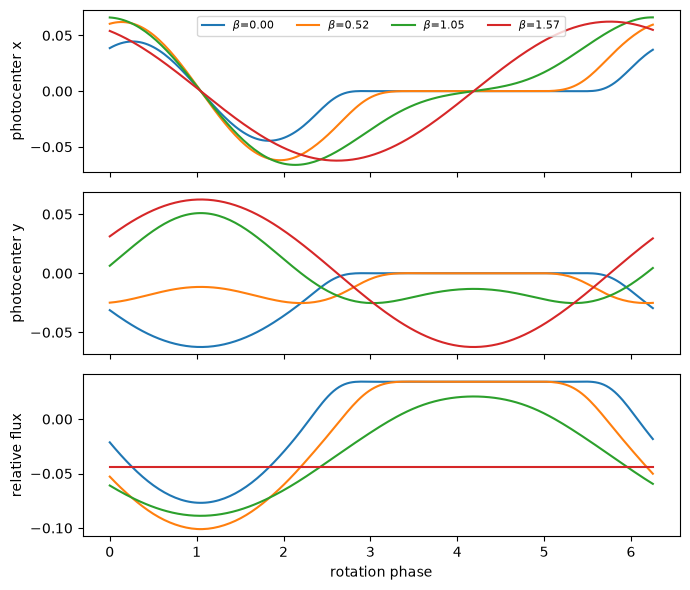

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True)
betas = [0.0, np.pi/6, np.pi/3, np.pi/2]
for beta in betas:
    y = fm.observe(s, inclination=beta, channels="xyp", stacked=False)
    for ax, c, name in zip(axes, "xyp", ["photocenter x", "photocenter y",
                                          "relative flux"]):
        ax.plot(times, y[c], label=f"$\\beta$={beta:.2f}")
        ax.set_ylabel(name)
axes[0].legend(ncol=4, fontsize=8); axes[-1].set_xlabel("rotation phase")
plt.tight_layout()

## Photocenter loci: pole-on jitter is circular

Plotting y vs. x photocenter shows the jitter shape directly. A key
worst-case result from the paper: for a pole-on observer
($\beta = \pi/2$), the astrometric jitter of *any* surface is a perfect
circle — rotation only advances the phase, never the shape — so surface
structure cannot be disentangled.

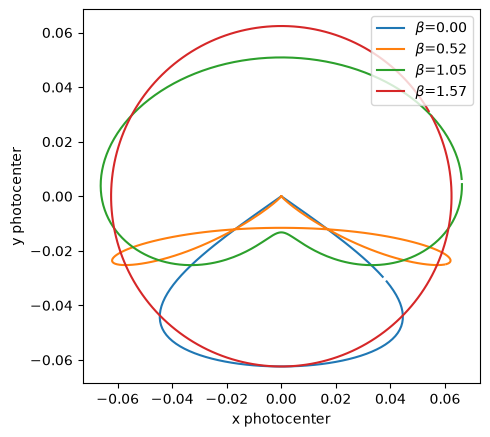

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
for beta in betas:
    y = fm.observe(s, inclination=beta, channels="xy", stacked=False)
    ax.plot(y["x"], y["y"], label=f"$\\beta$={beta:.2f}")
ax.set_xlabel("x photocenter"); ax.set_ylabel("y photocenter")
ax.set_aspect("equal"); ax.legend(); plt.tight_layout()

While the spot is on the far side of the star, the photocenter sits at the
origin; egress/ingress produce the cusp visible at low inclination (paper
Figs. 2–3).

## Spot latitude at fixed inclination

Paper Figure 3: at fixed $\beta = 30°$, higher-latitude spots produce
smaller photocenter excursions.

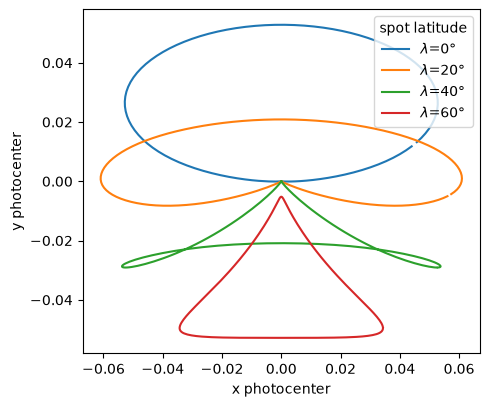

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
beta = np.pi/6
for lat in [0, 20, 40, 60]:
    s_lat = jm.multispot_surface([(lat, 300, jm.rfrac_to_deg(0.10))], L)
    y = fm.observe(s_lat, inclination=beta, channels="xy", stacked=False)
    ax.plot(y["x"], y["y"], label=f"$\\lambda$={lat}°")
ax.set_xlabel("x photocenter"); ax.set_ylabel("y photocenter")
ax.set_aspect("equal"); ax.legend(title="spot latitude"); plt.tight_layout()

## Realness and the Vandermonde fast path

For real-surface coefficients the modeled signals are real, and the design
matrix is built through the decomposition
$B(t) = \mathrm{diag}(e^{-im\omega t}) M_l$ — $O(NL^2)$ elementwise work,
no per-timepoint matrix products. The reference implementation is kept for
verification:

In [6]:
from jittermap.forward.design import design_matrix_reference, \
    design_matrix_vandermonde, precompute_vandermonde
from jittermap.forward.kernels import compute_A_lm

A_x, A_y = compute_A_lm(L)
D_ref = design_matrix_reference(times, L, 0.6, A_x)
D_fast = design_matrix_vandermonde(L, 0.6, A_x, *precompute_vandermonde(times, L))
print("fast path matches reference:", np.allclose(D_ref, D_fast))
print("max imaginary part of signal:", np.abs(fm.observe(s, 0.6, "xy").imag).max()
      if np.iscomplexobj(fm.observe(s, 0.6, "xy")) else 0.0)

fast path matches reference: True
max imaginary part of signal: 0.0
